In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
image = cv2.imread("color.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [9]:
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)
print(pixels)

[[ 3.  7. 26.]
 [ 3.  7. 26.]
 [ 3.  7. 26.]
 ...
 [ 4. 11. 27.]
 [ 4. 11. 27.]
 [ 4. 11. 27.]]


In [10]:
k = 8
when_stop = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

In [11]:
ret, labels, centers = cv2.kmeans(pixels, k, None, when_stop, 10, cv2.KMEANS_RANDOM_CENTERS)

In [12]:
centers = np.uint8(centers)
compressed = centers[labels.flatten()]
compressed = compressed.reshape(image.shape)

In [13]:
cv2.imwrite("compressed.jpg", cv2.cvtColor(compressed, cv2.COLOR_RGB2BGR))

True

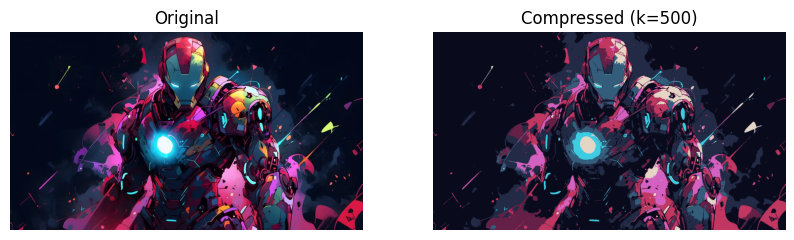

In [14]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Compressed (k=500)")
plt.imshow(compressed)
plt.axis('off')

plt.show()